<a href="https://colab.research.google.com/github/hsuanmiaochen/PdM-Proposal/blob/main/gaussianPlot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 模擬一組時間序列的特徵向量（這裡假設為 1 維）
time_steps = 50
x = np.linspace(0, 10, time_steps)
features = np.sin(x)  # 可以用 sin wave 或其它

# 計算 Gaussian kernel
sigma = 1.0
kernel_matrix = np.zeros((time_steps, time_steps))
for i in range(time_steps):
    for j in range(time_steps):
        diff = features[i] - features[j]
        kernel_matrix[i, j] = np.exp(- (diff**2) / (2 * sigma**2))


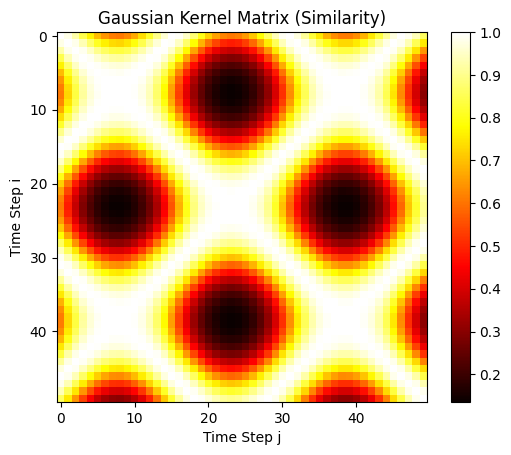

In [ ]:
plt.imshow(kernel_matrix, cmap='hot', interpolation='nearest')
plt.title('Gaussian Kernel Matrix (Similarity)')
plt.colorbar()
plt.xlabel('Time Step j')
plt.ylabel('Time Step i')
plt.show()


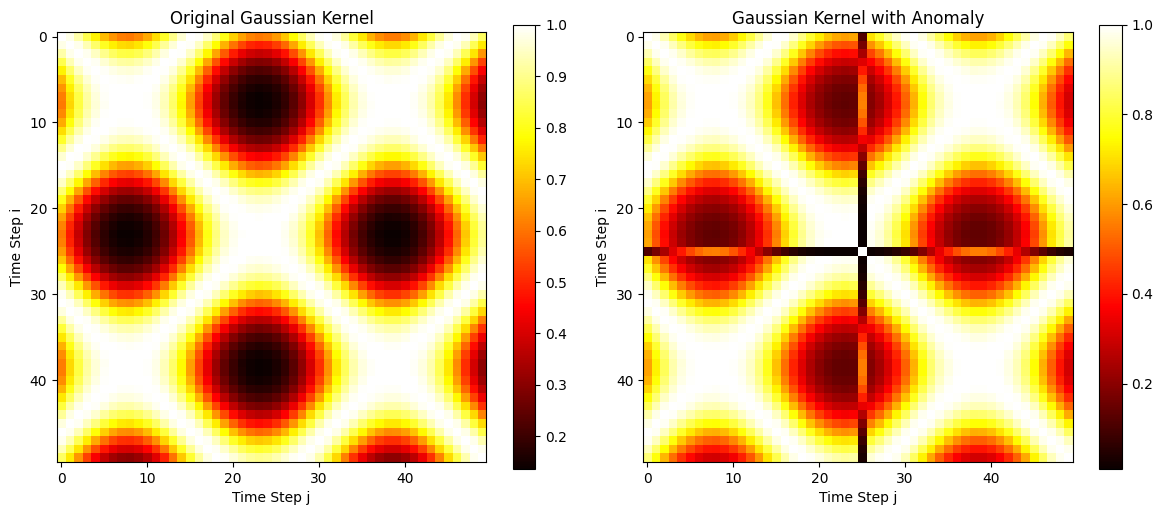

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: 建立時間序列（這裡使用 sin 波）
time_steps = 50
x = np.linspace(0, 10, time_steps)
features = np.sin(x)

# Step 2: 定義 Gaussian kernel 函數
def gaussian_kernel_matrix(data, sigma=1.0):
    N = len(data)
    matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            diff = data[i] - data[j]
            matrix[i, j] = np.exp(- (diff**2) / (2 * sigma**2))
    return matrix

# Step 3: 原始資料計算 kernel
kernel_matrix = gaussian_kernel_matrix(features, sigma=1.0)

# Step 4: 在第 26 個時間點加入異常值（+3）
features_with_anomaly = features.copy()
features_with_anomaly[25] += 3
kernel_matrix_anomaly = gaussian_kernel_matrix(features_with_anomaly, sigma=1.0)

# Step 5: 繪圖比較
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 原始圖
im0 = axs[0].imshow(kernel_matrix, cmap='hot', interpolation='nearest')
axs[0].set_title('Original Gaussian Kernel')
axs[0].set_xlabel('Time Step j')
axs[0].set_ylabel('Time Step i')
fig.colorbar(im0, ax=axs[0])

# 加入異常圖
im1 = axs[1].imshow(kernel_matrix_anomaly, cmap='hot', interpolation='nearest')
axs[1].set_title('Gaussian Kernel with Anomaly')
axs[1].set_xlabel('Time Step j')
axs[1].set_ylabel('Time Step i')
fig.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()
